In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lmfit import Model
from scipy.stats import chi2
import math as math
from scipy.ndimage import gaussian_filter1d
from pathlib import Path
import selfmadefunctions
import importlib
importlib.reload(selfmadefunctions)

# Author: Manou Liesker. Student number: 15250946

<module 'selfmadefunctions' from 'c:\\Users\\manou\\OneDrive\\Documenten\\GitHub\\paperstack\\Manou_version\\code\\selfmadefunctions.py'>

In [ ]:


selfmadefunctions.normalize_y(f"Results_zonderlucht_100")
    


Results_zonderlucht_100


In [73]:
# Generate lists and data
NETWORK_FOLDER = Path(rf"Z:\Clean_Data\Data_Manou_Maria_Clean")
T3_Thicknesses = [0, 20, 40, 60, 80, 100, 140, 180, 200, 250, 300, 350, 400, 500]
V_Thicknesses = [0, 1, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40]

# Liesker-Kieft daat
T_COR, T_COR_err = selfmadefunctions.calulate_COR(NETWORK_FOLDER, 'T3', T3_Thicknesses, 3, False) # (networkfolder, filebegin, thicknesslist, repetitions, Plot)
V_COR, V_COR_err = selfmadefunctions.calulate_COR(NETWORK_FOLDER, 'V', V_Thicknesses, 3, False)

# Saladin Data
A4_Thickness, A4_COR, A4_COR_err = selfmadefunctions.read_saladin_data("A4_sanitized_data.csv", False)
A5B_Thickness, A5B_COR, A5B_COR_err = selfmadefunctions.read_saladin_data("A5_B_sanitized_data.csv", False)
A5O_Thickness, A5O_COR, A5O_COR_err = selfmadefunctions.read_saladin_data("A5_O_sanitized_data.csv", False)

Below I used the self made functions in selfmadefunctions.py to reprocess the data from 2024 I collected with Maria.

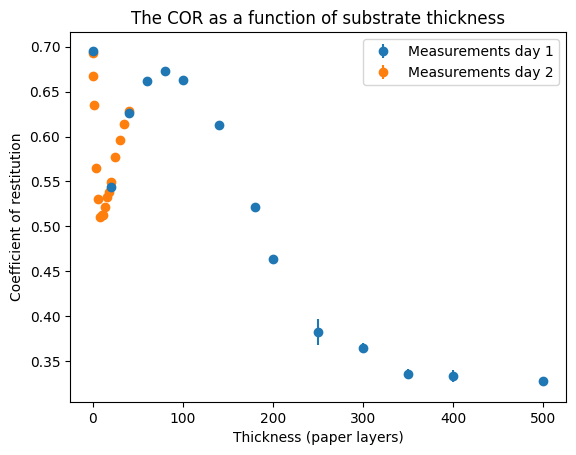

In [74]:
plt.errorbar(T3_Thicknesses, T_COR, yerr= T_COR_err, fmt = 'o', label = "Measurements day 1", zorder = 1)
plt.errorbar(V_Thicknesses, V_COR, yerr= V_COR_err, fmt = 'o', label = "Measurements day 2", zorder = 0)
plt.title('The COR as a function of substrate thickness')
plt.xlabel('Thickness (paper layers)')
plt.ylabel('Coefficient of restitution')
plt.legend()
plt.show()

I will now recreate 1st year students graph and combine with my graph. I would like his raw data to compare our data analysis methods.

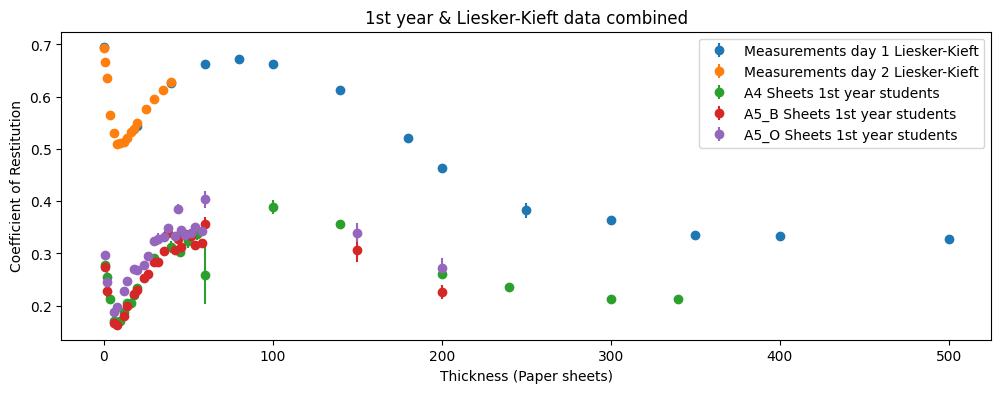

In [75]:
plt.figure(figsize = (12,4))
plt.errorbar(T3_Thicknesses, T_COR, yerr= T_COR_err, fmt = 'o', label = "Measurements day 1 Liesker-Kieft")
plt.errorbar(V_Thicknesses, V_COR, yerr= V_COR_err, fmt = 'o', label = "Measurements day 2 Liesker-Kieft")
plt.errorbar(A4_Thickness, A4_COR, yerr = A4_COR_err, fmt = 'o', label = 'A4 Sheets 1st year students')
plt.errorbar(A5B_Thickness, A5B_COR, yerr = A5B_COR_err, fmt = 'o', label = 'A5_B Sheets 1st year students')
plt.errorbar(A5O_Thickness, A5O_COR, yerr = A5O_COR_err, fmt = 'o', label = 'A5_O Sheets 1st year students')
plt.title("1st year & Liesker-Kieft data combined")
plt.xlabel("Thickness (Paper sheets)")
plt.ylabel("Coefficient of Restitution")
plt.legend()
plt.show()